# Explainable CNN-Based Casting Product Defect Classification
**Custom CNN vs. EfficientNetV2 vs. ConvNeXtTiny — with Grad-CAM, SHAP, and efficiency analysis**

Author: **Eren Köse** (Matric. 62675606) — University of Europe for Applied Sciences

This notebook is self-contained and runs top-to-bottom on Kaggle.

### Before you run (Kaggle settings, right-hand panel)
1. **Accelerator → GPU** (T4 or P100).
2. **Internet → On** (needed once so Keras can download the ImageNet weights for EfficientNetV2 / ConvNeXt). Requires a phone-verified Kaggle account.
3. **Add Input →** search and attach *Casting Product Image Data for Quality Inspection*.

### Research questions
- **RQ1** accuracy of CNNs at defective vs OK classification
- **RQ2** does transfer learning beat the custom CNN (esp. defective recall)
- **RQ3** do Grad-CAM / SHAP attend to real defect regions
- **RQ4** best accuracy / false-negative / efficiency trade-off
- **RQ5** is the chosen model deployable as a web prototype

In [1]:
# ============================================================
# 0. Imports, reproducibility, and configuration
# ============================================================
import os, glob, time, random, json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_score,
                             recall_score, f1_score, accuracy_score)

# Reproducibility: fix every RNG so the run is repeatable.
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# All knobs in one place for easy editing during debugging.
IMG_SIZE    = 224     # EfficientNetV2 / ConvNeXt expect ~224x224 inputs
BATCH_SIZE  = 32
HEAD_EPOCHS = 12      # transfer stage 1: train new head, backbone frozen
FINE_EPOCHS = 8       # transfer stage 2: fine-tune top backbone layers
CNN_EPOCHS  = 25      # custom CNN trained from scratch
VAL_SPLIT   = 0.15    # carve 15% of the official TRAIN set as validation
AUTOTUNE    = tf.data.AUTOTUNE

# Positive class = DEFECTIVE. A false negative (defective predicted OK) is the
# costly error in inspection, so we make "defective" the label we optimise for.
CLASS_TO_LABEL = {"def_front": 1, "ok_front": 0}   # 1 = defective, 0 = OK
LABEL_TO_NAME  = {1: "defective", 0: "ok"}

OUT_DIR = "/kaggle/working/results"
os.makedirs(OUT_DIR, exist_ok=True)

print("TensorFlow", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

2026-06-22 18:55:47.216035: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782154547.400912      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782154547.451882      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782154547.906547      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782154547.906591      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782154547.906594      24 computation_placer.cc:177] computation placer alr

TensorFlow 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset — locating and inspecting the casting images

In [2]:
# ============================================================
# 1. Locate the dataset on Kaggle (robust to the exact mount path)
# ============================================================
# Rather than hard-coding a path, we search for the train/test folders that
# contain the def_front / ok_front class subfolders. This survives dataset
# renames and the slightly different folder nesting Kaggle sometimes uses.
def find_split_dir(split):
    hits = glob.glob(f"/kaggle/input/**/{split}/def_front", recursive=True)
    return os.path.dirname(hits[0]) if hits else None

train_dir = find_split_dir("train")
test_dir  = find_split_dir("test")
assert train_dir and test_dir, (
    "Could not find train/test folders. Use 'Add Input' to attach the "
    "'Casting Product Image Data for Quality Inspection' dataset.")
print("Train dir:", train_dir)
print("Test  dir:", test_dir)

Train dir: /kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train
Test  dir: /kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test


In [3]:
# ============================================================
# 2. Gather file paths + labels, then make a STRATIFIED val split
# ============================================================
def list_files_labels(split_dir):
    paths, labels = [], []
    for cls, lab in CLASS_TO_LABEL.items():
        for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
            for p in glob.glob(os.path.join(split_dir, cls, ext)):
                paths.append(p); labels.append(lab)
    return np.array(paths), np.array(labels)

train_paths_all, train_labels_all = list_files_labels(train_dir)
test_paths, test_labels = list_files_labels(test_dir)

# Stratify keeps the defective/OK ratio identical in train and val, which
# matters because the dataset is imbalanced (more defective than OK).
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths_all, train_labels_all,
    test_size=VAL_SPLIT, stratify=train_labels_all, random_state=SEED)

def summarize(name, labels):
    print(f"{name:5s}: {len(labels):5d} | defective {int((labels==1).sum()):5d}"
          f"  ok {int((labels==0).sum()):5d}")
summarize("train", train_labels); summarize("val", val_labels); summarize("test", test_labels)

# Class weights counter the imbalance during training (used by all models).
n_total = len(train_labels)
class_weight = {0: n_total / (2.0 * (train_labels == 0).sum()),
                1: n_total / (2.0 * (train_labels == 1).sum())}
print("Class weights:", class_weight)

train:  5638 | defective  3194  ok  2444
val  :   995 | defective   564  ok   431
test :   715 | defective   453  ok   262
Class weights: {0: np.float64(1.1534369885433715), 1: np.float64(0.882592360676268)}


In [4]:
# ============================================================
# 3. Build tf.data input pipelines
# ============================================================
# Images are decoded with 3 channels (grayscale casting images get replicated to
# RGB) and kept in [0,255]. EfficientNetV2 and ConvNeXt include their OWN
# normalization, and the custom CNN rescales internally, so one pipeline can feed
# all three models.
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return tf.cast(img, tf.float32), label

# Augment TRAIN only. Rotation/flip/zoom are valid because a casting part can
# appear in any orientation; we keep magnitudes small so tiny defects survive.
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augment")

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
    if training:
        ds = ds.map(lambda x, y: (augment(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_ds(train_paths, train_labels, training=True)
val_ds   = make_ds(val_paths,   val_labels)
test_ds  = make_ds(test_paths,  test_labels)

I0000 00:00:1782154568.373532      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


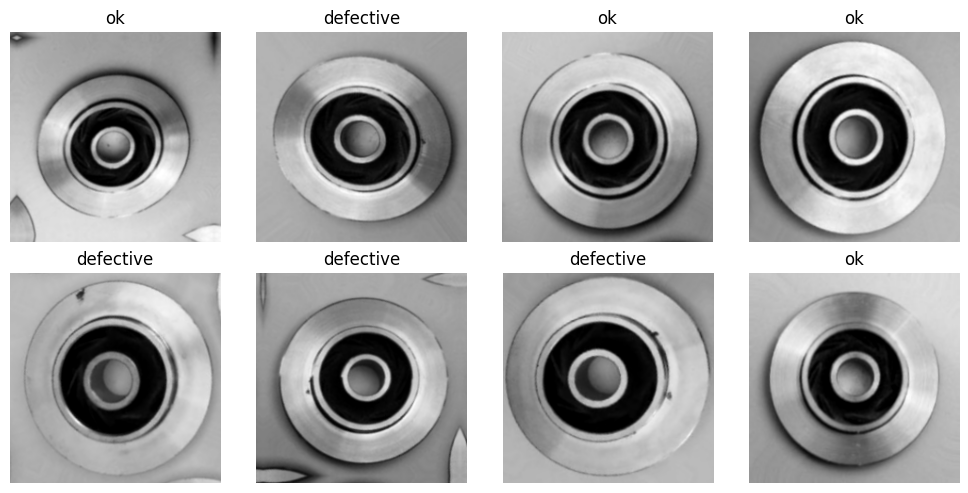

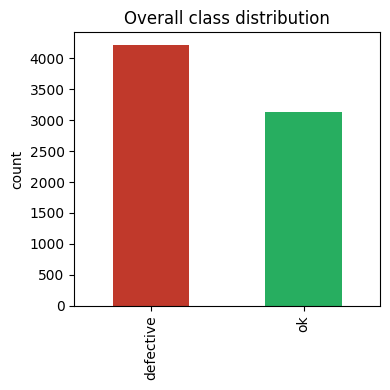

In [5]:
# ============================================================
# 4. Visualize sample images + class distribution
# ============================================================
plt.figure(figsize=(10, 5))
for imgs, labs in train_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(imgs[i].numpy().astype("uint8"))
        plt.title(LABEL_TO_NAME[int(labs[i])]); plt.axis("off")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/sample_images.png", dpi=150); plt.show()

dist = pd.Series(np.concatenate([train_labels, val_labels, test_labels])).map(LABEL_TO_NAME)
plt.figure(figsize=(4, 4)); dist.value_counts().plot.bar(color=["#c0392b", "#27ae60"])
plt.title("Overall class distribution"); plt.ylabel("count")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/class_distribution.png", dpi=150); plt.show()

## 2. Models — custom CNN baseline + two transfer-learning backbones

In [6]:
# ============================================================
# 5. Model 1 - Custom CNN baseline (trained from scratch)
# ============================================================
def build_custom_cnn():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Rescaling(1.0 / 255)(inputs)            # [0,255] -> [0,1]
    for f in (32, 64, 128, 128):
        x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)  # P(defective)
    model = keras.Model(inputs, outputs, name="custom_cnn")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy",
                           keras.metrics.Precision(name="precision"),
                           keras.metrics.Recall(name="recall"),
                           keras.metrics.AUC(name="auc")])
    return model

custom_cnn = build_custom_cnn()
custom_cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,881 (1011.25 KB)

 Trainable params: 258,177 (1008.50 KB)

 Non-trainable params: 704 (2.75 KB)

In [7]:
# ============================================================
# 6. Transfer-learning model builder (FLAT graph -> easy Grad-CAM)
# ============================================================
# We attach the backbone with input_tensor=inputs so its layers become
# top-level layers of our model (a "flat" graph). That makes Grad-CAM - which
# needs a specific conv layer's output - simple to wire up later.
def build_transfer_model(backbone_fn, name):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = backbone_fn(include_top=False, weights="imagenet", input_tensor=inputs)
    base.trainable = False                              # stage 1: freeze
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy",
                           keras.metrics.Precision(name="precision"),
                           keras.metrics.Recall(name="recall"),
                           keras.metrics.AUC(name="auc")])
    return model, base

effnet,   effnet_base   = build_transfer_model(keras.applications.EfficientNetV2B0, "efficientnet_v2b0")
convnext, convnext_base = build_transfer_model(keras.applications.ConvNeXtTiny,    "convnext_tiny")

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


## 3. Training

In [8]:
# ============================================================
# 7. Shared callbacks + train Model 1 (custom CNN)
# ============================================================
def make_callbacks(tag):
    return [
        keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                      patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                                          patience=3, min_lr=1e-6),
        keras.callbacks.ModelCheckpoint(f"{OUT_DIR}/{tag}_best.keras",
                                        monitor="val_auc", mode="max",
                                        save_best_only=True),
    ]

histories, train_times = {}, {}
t0 = time.time()
histories["custom_cnn"] = custom_cnn.fit(
    train_ds, validation_data=val_ds, epochs=CNN_EPOCHS,
    class_weight=class_weight, callbacks=make_callbacks("custom_cnn")).history
train_times["custom_cnn"] = time.time() - t0

Epoch 1/25


I0000 00:00:1782154587.880636      67 service.cc:152] XLA service 0x7fb29c001d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782154587.880678      67 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782154589.157344      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/177 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.6146 - auc: 0.7387 - loss: 0.6125 - precision: 0.7490 - recall: 0.3836  

I0000 00:00:1782154595.332629      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


177/177 ━━━━━━━━━━━━━━━━━━━━ 47s 203ms/step - accuracy: 0.8421 - auc: 0.9155 - loss: 0.3720 - precision: 0.8792 - recall: 0.8363 - val_accuracy: 0.4241 - val_auc: 0.1422 - val_loss: 0.8578 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/25
177/177 ━━━━━━━━━━━━━━━━━━━━ 27s 148ms/step - accuracy: 0.9104 - auc: 0.9681 - loss: 0.2191 - precision: 0.9513 - recall: 0.8873 - val_accuracy: 0.4332 - val_auc: 0.5000 - val_loss: 4.2109 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/25
177/177 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - accuracy: 0.9445 - auc: 0.9862 - loss: 0.1458 - precision: 0.9697 - recall: 0.9311 - val_accuracy: 0.5628 - val_auc: 0.4709 - val_loss: 9.3065 - val_precision: 0.5671 - val_recall: 0.9663 - learning_rate: 0.0010
Epoch 4/25
177/177 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - accuracy: 0.9711 - auc: 0.9949 - loss: 0.0830 - precision: 0.9843 - recall: 0.9643 - val_accuracy: 0.7558 - val_auc: 0.9937 - val_l

In [9]:
# ============================================================
# 8. Train transfer models - stage 1 (frozen) then stage 2 (fine-tune)
# ============================================================
def fit_transfer(model, base, tag):
    t0 = time.time()
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=HEAD_EPOCHS,
                   class_weight=class_weight, callbacks=make_callbacks(tag + "_s1")).history
    # Stage 2: unfreeze the top ~30% of backbone layers, fine-tune at a low LR.
    base.trainable = True
    n_freeze = int(len(base.layers) * 0.7)
    for layer in base.layers[:n_freeze]:
        layer.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(1e-5),
                  loss="binary_crossentropy",
                  metrics=["accuracy",
                           keras.metrics.Precision(name="precision"),
                           keras.metrics.Recall(name="recall"),
                           keras.metrics.AUC(name="auc")])
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=FINE_EPOCHS,
                   class_weight=class_weight, callbacks=make_callbacks(tag + "_s2")).history
    merged = {k: h1[k] + h2.get(k, []) for k in h1}     # join stages for plotting
    return merged, time.time() - t0

histories["efficientnet_v2b0"], train_times["efficientnet_v2b0"] = fit_transfer(effnet, effnet_base, "efficientnet_v2b0")
histories["convnext_tiny"],     train_times["convnext_tiny"]     = fit_transfer(convnext, convnext_base, "convnext_tiny")

Epoch 1/12
177/177 ━━━━━━━━━━━━━━━━━━━━ 72s 267ms/step - accuracy: 0.7568 - auc: 0.8588 - loss: 0.5148 - precision: 0.8233 - recall: 0.7267 - val_accuracy: 0.9186 - val_auc: 0.9921 - val_loss: 0.3530 - val_precision: 0.9979 - val_recall: 0.8582 - learning_rate: 0.0010
Epoch 2/12
177/177 ━━━━━━━━━━━━━━━━━━━━ 27s 151ms/step - accuracy: 0.8987 - auc: 0.9662 - loss: 0.3254 - precision: 0.9462 - recall: 0.8707 - val_accuracy: 0.9518 - val_auc: 0.9953 - val_loss: 0.2519 - val_precision: 1.0000 - val_recall: 0.9149 - learning_rate: 0.0010
Epoch 3/12
177/177 ━━━━━━━━━━━━━━━━━━━━ 27s 152ms/step - accuracy: 0.9228 - auc: 0.9772 - loss: 0.2630 - precision: 0.9600 - recall: 0.9014 - val_accuracy: 0.9618 - val_auc: 0.9961 - val_loss: 0.2046 - val_precision: 1.0000 - val_recall: 0.9326 - learning_rate: 0.0010
Epoch 4/12
177/177 ━━━━━━━━━━━━━━━━━━━━ 27s 152ms/step - accuracy: 0.9296 - auc: 0.9821 - loss: 0.2265 - precision: 0.9623 - recall: 0.9114 - val_accuracy: 0.9548 - val_auc: 0.9964 - val_loss: 

2026-06-22 19:13:12.583708: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-22 19:13:12.790588: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


177/177 ━━━━━━━━━━━━━━━━━━━━ 91s 293ms/step - accuracy: 0.9133 - auc: 0.9669 - loss: 0.2425 - precision: 0.9320 - recall: 0.9136 - val_accuracy: 0.9759 - val_auc: 0.9970 - val_loss: 0.0963 - val_precision: 0.9963 - val_recall: 0.9610 - learning_rate: 1.0000e-05
Epoch 2/8
177/177 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - accuracy: 0.9484 - auc: 0.9883 - loss: 0.1509 - precision: 0.9751 - recall: 0.9327 - val_accuracy: 0.9859 - val_auc: 0.9975 - val_loss: 0.0614 - val_precision: 0.9946 - val_recall: 0.9805 - learning_rate: 1.0000e-05
Epoch 3/8
177/177 ━━━━━━━━━━━━━━━━━━━━ 28s 156ms/step - accuracy: 0.9613 - auc: 0.9913 - loss: 0.1229 - precision: 0.9806 - recall: 0.9505 - val_accuracy: 0.9879 - val_auc: 0.9980 - val_loss: 0.0556 - val_precision: 0.9982 - val_recall: 0.9805 - learning_rate: 1.0000e-05
Epoch 4/8
177/177 ━━━━━━━━━━━━━━━━━━━━ 29s 159ms/step - accuracy: 0.9725 - auc: 0.9943 - loss: 0.0956 - precision: 0.9881 - recall: 0.9631 - val_accuracy: 0.9899 - val_auc: 0.9987 - val_loss: 0.

2026-06-22 19:24:11.476360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-22 19:24:11.653384: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-22 19:24:11.890651: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-22 19:24:12.085797: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


176/177 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9678 - auc: 0.9952 - loss: 0.0979 - precision: 0.9812 - recall: 0.9626

2026-06-22 19:24:54.828930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-22 19:24:55.004740: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


177/177 ━━━━━━━━━━━━━━━━━━━━ 80s 302ms/step - accuracy: 0.9773 - auc: 0.9962 - loss: 0.0775 - precision: 0.9882 - recall: 0.9715 - val_accuracy: 0.9668 - val_auc: 0.9990 - val_loss: 0.1064 - val_precision: 0.9492 - val_recall: 0.9947 - learning_rate: 1.0000e-05
Epoch 2/8
177/177 ━━━━━━━━━━━━━━━━━━━━ 36s 200ms/step - accuracy: 0.9917 - auc: 0.9985 - loss: 0.0326 - precision: 0.9959 - recall: 0.9894 - val_accuracy: 0.9899 - val_auc: 0.9995 - val_loss: 0.0342 - val_precision: 0.9894 - val_recall: 0.9929 - learning_rate: 1.0000e-05
Epoch 3/8
177/177 ━━━━━━━━━━━━━━━━━━━━ 36s 200ms/step - accuracy: 0.9956 - auc: 0.9991 - loss: 0.0216 - precision: 0.9991 - recall: 0.9931 - val_accuracy: 0.9879 - val_auc: 0.9996 - val_loss: 0.0358 - val_precision: 0.9842 - val_recall: 0.9947 - learning_rate: 1.0000e-05
Epoch 4/8
177/177 ━━━━━━━━━━━━━━━━━━━━ 36s 200ms/step - accuracy: 0.9945 - auc: 0.9992 - loss: 0.0201 - precision: 0.9978 - recall: 0.9925 - val_accuracy: 0.9920 - val_auc: 0.9996 - val_loss: 0.

## 4. Evaluation

In [10]:
# ============================================================
# 9. Evaluate all models on the untouched TEST set
# ============================================================
models = {"custom_cnn": custom_cnn,
          "efficientnet_v2b0": effnet,
          "convnext_tiny": convnext}

# Cache test images/labels once for metrics and the XAI sections.
test_images = np.concatenate([x.numpy() for x, _ in test_ds], axis=0)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0).astype(int)

def evaluate(model):
    t0 = time.time(); probs = model.predict(test_ds, verbose=0).ravel()
    infer_ms = (time.time() - t0) / len(y_true) * 1000.0
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y_true, preds, labels=[0, 1])  # [[tn,fp],[fn,tp]]
    tn, fp, fn, tp = cm.ravel()
    fn_rate = fn / (fn + tp) if (fn + tp) else 0.0        # share of missed defectives
    return {"accuracy": accuracy_score(y_true, preds),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall_def": recall_score(y_true, preds, zero_division=0),
            "f1": f1_score(y_true, preds, zero_division=0),
            "roc_auc": roc_auc_score(y_true, probs),
            "false_neg_rate": fn_rate, "false_negatives": int(fn),
            "params_M": model.count_params() / 1e6,
            "infer_ms_per_img": infer_ms,
            "_probs": probs, "_preds": preds, "_cm": cm}

results = {name: evaluate(m) for name, m in models.items()}
cols = ["accuracy", "precision", "recall_def", "f1", "roc_auc",
        "false_neg_rate", "false_negatives", "params_M", "infer_ms_per_img"]
summary = pd.DataFrame({n: {c: results[n][c] for c in cols} for n in models}).T
summary["train_time_s"] = pd.Series(train_times)
summary.to_csv(f"{OUT_DIR}/model_comparison.csv")
summary.round(4)

,accuracy,precision,recall_def,f1,roc_auc,false_neg_rate,false_negatives,params_M,infer_ms_per_img,train_time_s
custom_cnn,0.9930,0.9912,0.9978,0.9945,0.9999,0.0022,1.0,0.2589,2.6093,608.3559
efficientnet_v2b0,0.9902,0.9978,0.9868,0.9922,0.9992,0.0132,6.0,5.9206,17.5306,661.4018
convnext_tiny,0.9846,0.9825,0.9934,0.9879,0.9996,0.0066,3.0,27.8209,13.6761,710.9990


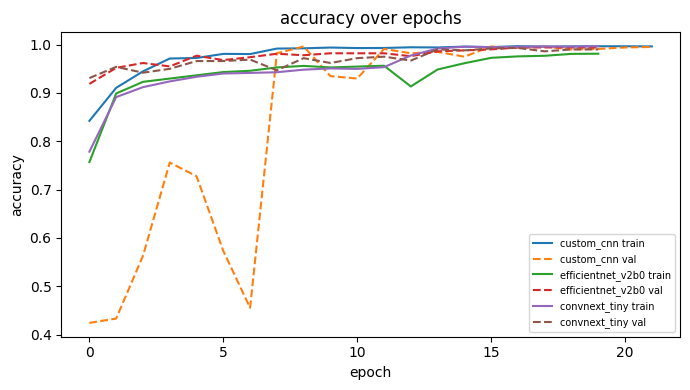

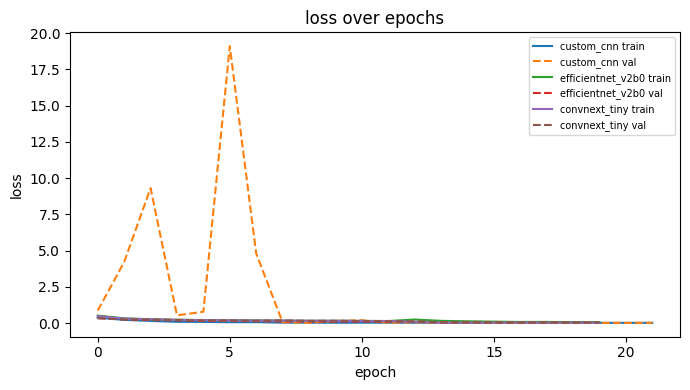

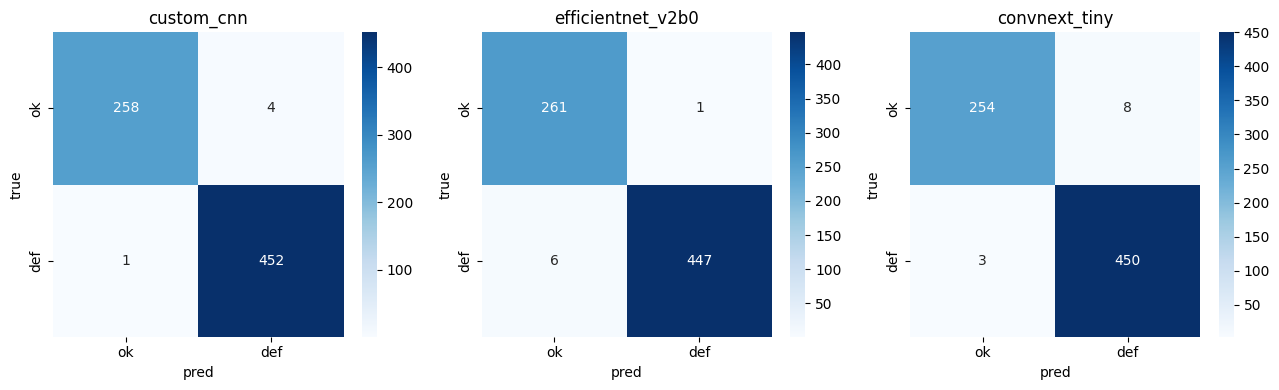

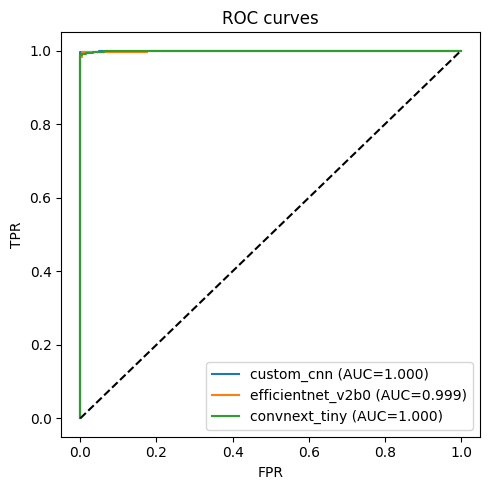


=== custom_cnn ===
              precision    recall  f1-score   support

          ok       1.00      0.98      0.99       262
   defective       0.99      1.00      0.99       453

    accuracy                           0.99       715
   macro avg       0.99      0.99      0.99       715
weighted avg       0.99      0.99      0.99       715


=== efficientnet_v2b0 ===
              precision    recall  f1-score   support

          ok       0.98      1.00      0.99       262
   defective       1.00      0.99      0.99       453

    accuracy                           0.99       715
   macro avg       0.99      0.99      0.99       715
weighted avg       0.99      0.99      0.99       715


=== convnext_tiny ===
              precision    recall  f1-score   support

          ok       0.99      0.97      0.98       262
   defective       0.98      0.99      0.99       453

    accuracy                           0.98       715
   macro avg       0.99      0.98      0.98       715
weig

In [11]:
# ============================================================
# 10. Plots: training curves, confusion matrices, ROC curves
# ============================================================
for metric in ("accuracy", "loss"):
    plt.figure(figsize=(7, 4))
    for name, h in histories.items():
        plt.plot(h[metric], label=f"{name} train")
        plt.plot(h["val_" + metric], "--", label=f"{name} val")
    plt.title(f"{metric} over epochs"); plt.xlabel("epoch"); plt.ylabel(metric)
    plt.legend(fontsize=7); plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/curves_{metric}.png", dpi=150); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(r["_cm"], annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["ok", "def"], yticklabels=["ok", "def"])
    ax.set_title(name); ax.set_xlabel("pred"); ax.set_ylabel("true")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/confusion_matrices.png", dpi=150); plt.show()

plt.figure(figsize=(5, 5))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_true, r["_probs"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC curves"); plt.legend(); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/roc_curves.png", dpi=150); plt.show()

for name in models:
    print("\n===", name, "===")
    print(classification_report(y_true, results[name]["_preds"],
                                target_names=["ok", "defective"], zero_division=0))

In [12]:
# ============================================================
# 11. Select the best model (fewest missed defectives, then best F1)
# ============================================================
# Missing a defective part is the worst outcome for inspection, so rank by
# false-negative rate first and break ties with F1.
best_name = sorted(models, key=lambda n: (results[n]["false_neg_rate"],
                                          -results[n]["f1"]))[0]
best_model = models[best_name]
print("Best model:", best_name)

Best model: custom_cnn


## 5. Explainable AI — Grad-CAM and SHAP (RQ3)

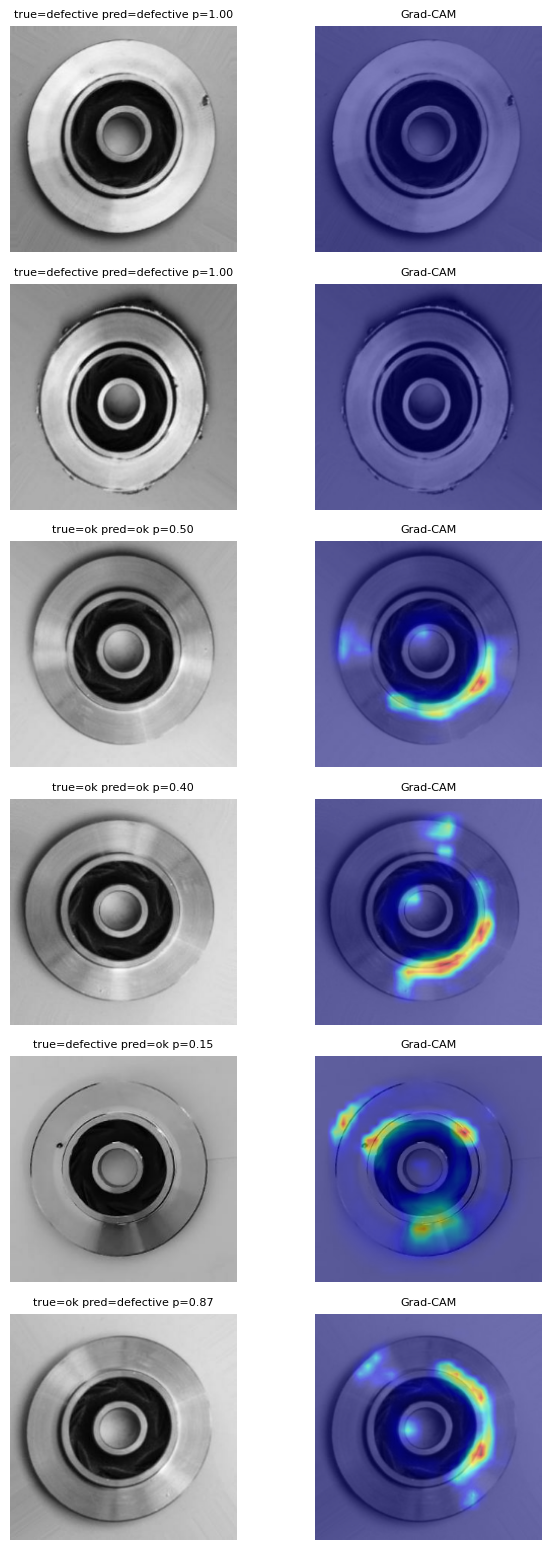

In [13]:
# ============================================================
# 12. Grad-CAM - is the model looking at the actual defect?
# ============================================================
def last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found.")

def grad_cam(model, image, conv_name):
    grad_model = keras.models.Model(model.inputs,
                                    [model.get_layer(conv_name).output, model.output])
    img = tf.convert_to_tensor(image[None], dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img)
        loss = preds[:, 0]                          # P(defective)
    grads = tape.gradient(loss, conv_out)[0]
    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam = tf.nn.relu(tf.reduce_sum(conv_out[0] * weights, axis=-1))
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    return tf.image.resize(cam[..., None], [IMG_SIZE, IMG_SIZE])[..., 0].numpy()

conv_name = last_conv_layer_name(best_model)
probs_b, preds_b = results[best_name]["_probs"], results[best_name]["_preds"]

# Informative examples: confident-correct, uncertain-correct, and mistakes.
order = np.argsort(np.abs(probs_b - 0.5))
correct_conf = [i for i in order[::-1] if preds_b[i] == y_true[i]][:2]
correct_unc  = [i for i in order       if preds_b[i] == y_true[i]][:2]
mistakes     = [i for i in range(len(y_true)) if preds_b[i] != y_true[i]][:2]
picks = correct_conf + correct_unc + mistakes

plt.figure(figsize=(7, 2.6 * len(picks)))
for j, i in enumerate(picks):
    cam = grad_cam(best_model, test_images[i], conv_name)
    plt.subplot(len(picks), 2, 2 * j + 1)
    plt.imshow(test_images[i].astype("uint8")); plt.axis("off")
    plt.title(f"true={LABEL_TO_NAME[y_true[i]]} pred={LABEL_TO_NAME[int(preds_b[i])]} p={probs_b[i]:.2f}", fontsize=8)
    plt.subplot(len(picks), 2, 2 * j + 2)
    plt.imshow(test_images[i].astype("uint8")); plt.imshow(cam, cmap="jet", alpha=0.5)
    plt.axis("off"); plt.title("Grad-CAM", fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/gradcam.png", dpi=150); plt.show()

  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [00:29<00:00,  5.89s/it]

  0%|          | 0/298 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:39, 13.00s/it]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.9578387..254.0893].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.9352646..247.81212].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.4663873..251.96031].


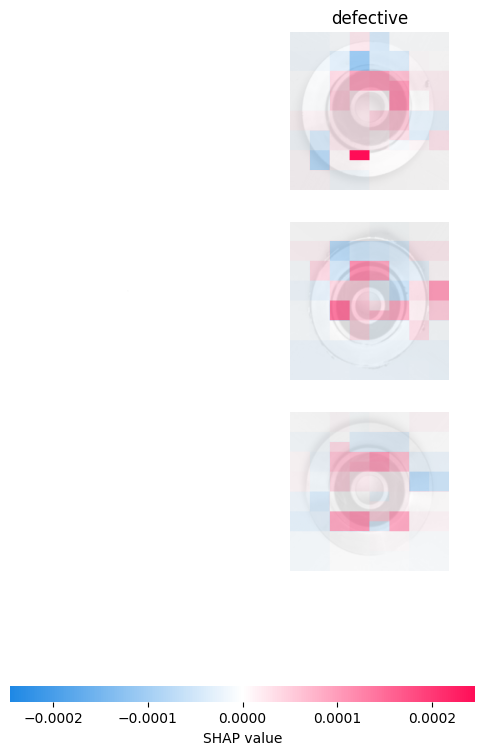

In [14]:
# ============================================================
# 13. SHAP - pixel/region contributions for the best model
# ============================================================
# SHAP image explanations are heavy, so we run a few test images only, using the
# model-agnostic Image masker (treats the model as a black box -> robust across
# TF versions). Wrapped in try/except so a SHAP hiccup never blocks the notebook.
try:
    import shap
    def f(x):
        return best_model.predict(x, verbose=0)
    masker = shap.maskers.Image("inpaint_telea", test_images[0].shape)
    explainer = shap.Explainer(f, masker, output_names=["defective"])
    sample = test_images[np.array(picks[:3])]
    shap_values = explainer(sample, max_evals=300, batch_size=BATCH_SIZE)
    shap.image_plot(shap_values, show=False)
    plt.savefig(f"{OUT_DIR}/shap.png", dpi=150, bbox_inches="tight"); plt.show()
except Exception as e:
    print("SHAP step skipped due to:", repr(e))

## 6. Robustness on degraded images

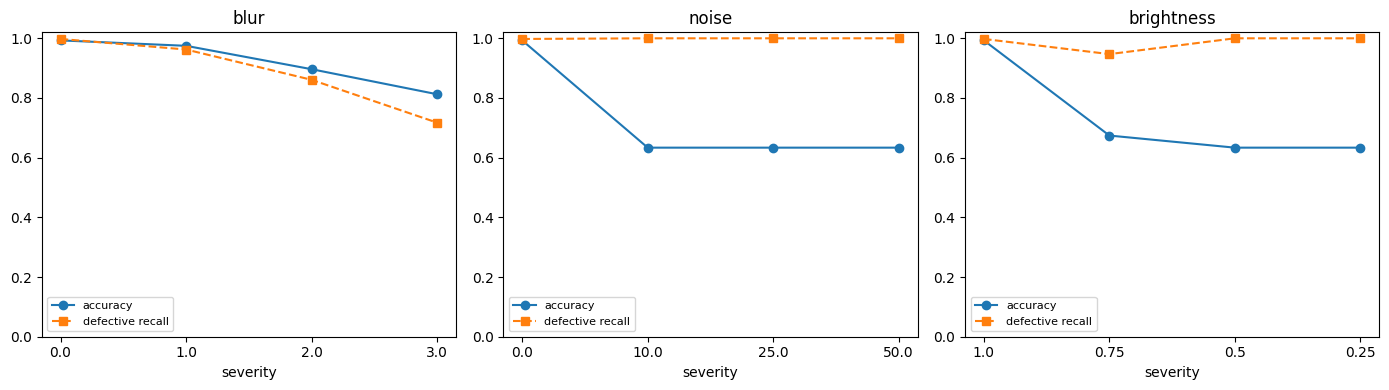

,degradation,level,accuracy,recall_def
0,blur,0.00,0.9930,0.9978
1,blur,1.00,0.9748,0.9625
2,blur,2.00,0.8965,0.8609
3,blur,3.00,0.8126,0.7174
4,noise,0.00,0.9930,0.9978
5,noise,10.00,0.6336,1.0000
6,noise,25.00,0.6336,1.0000
7,noise,50.00,0.6336,1.0000
8,brightness,1.00,0.9930,0.9978
9,brightness,0.75,0.6741,0.9470


In [15]:
# ============================================================
# 14. Robustness check - does the best model survive worse image quality?
# ============================================================
# Real inspection photos are noisier than this clean dataset, so we test the best
# model on copies of the TEST set that we degrade on purpose: Gaussian blur, added
# random noise, and reduced brightness, each at a few severity levels. We watch
# accuracy and, more importantly, defective recall, since missing defects is the
# costly error.
import scipy.ndimage as ndi

def degrade(images, kind, level):
    x = images.copy().astype(np.float32)
    if kind == "blur":            # level = Gaussian sigma in pixels (0 = no blur)
        x = ndi.gaussian_filter(x, sigma=(0, level, level, 0))
    elif kind == "noise":         # level = noise std dev on the 0-255 scale
        x = x + np.random.normal(0, level, x.shape)
    elif kind == "brightness":    # level = multiplier on pixel values (1.0 = clean)
        x = x * level
    return np.clip(x, 0, 255)

severities = {
    "blur":       [0, 1, 2, 3],
    "noise":      [0, 10, 25, 50],
    "brightness": [1.0, 0.75, 0.5, 0.25],
}

rob_rows = []
for kind, levels in severities.items():
    for lv in levels:
        xd = degrade(test_images, kind, lv)
        pred = (best_model.predict(xd, verbose=0).ravel() >= 0.5).astype(int)
        rob_rows.append({"degradation": kind, "level": lv,
                         "accuracy": accuracy_score(y_true, pred),
                         "recall_def": recall_score(y_true, pred, zero_division=0)})

rob_df = pd.DataFrame(rob_rows)
rob_df.to_csv(f"{OUT_DIR}/robustness.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, kind in zip(axes, severities):
    sub = rob_df[rob_df["degradation"] == kind]
    ax.plot(range(len(sub)), sub["accuracy"], "o-", label="accuracy")
    ax.plot(range(len(sub)), sub["recall_def"], "s--", label="defective recall")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["level"].tolist())
    ax.set_title(kind); ax.set_xlabel("severity"); ax.set_ylim(0, 1.02); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/robustness.png", dpi=150); plt.show()
rob_df.round(4)

## 7. Save results

In [16]:
# ============================================================
# 15. Save metrics + best model, then zip the results folder
# ============================================================
summary.round(5).to_csv(f"{OUT_DIR}/model_comparison.csv")
with open(f"{OUT_DIR}/summary.json", "w") as fp:
    json.dump({n: {c: float(results[n][c]) for c in cols} for n in models}, fp, indent=2)

best_model.save(f"{OUT_DIR}/best_model_{best_name}.keras")

zip_path = "/kaggle/working/casting_results.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(OUT_DIR):
        for fn in files:
            full = os.path.join(root, fn)
            zf.write(full, os.path.relpath(full, OUT_DIR))
print("Best model:", best_name, "| results zipped at", zip_path)
summary.round(4)

Best model: custom_cnn | results zipped at /kaggle/working/casting_results.zip


,accuracy,precision,recall_def,f1,roc_auc,false_neg_rate,false_negatives,params_M,infer_ms_per_img,train_time_s
custom_cnn,0.9930,0.9912,0.9978,0.9945,0.9999,0.0022,1.0,0.2589,2.6093,608.3559
efficientnet_v2b0,0.9902,0.9978,0.9868,0.9922,0.9992,0.0132,6.0,5.9206,17.5306,661.4018
convnext_tiny,0.9846,0.9825,0.9934,0.9879,0.9996,0.0066,3.0,27.8209,13.6761,710.9990


## 8. Summary mapped to the research questions

| RQ | Answered by |
|----|-------------|
| RQ1 accuracy | Section 9 comparison table, Section 10 confusion matrices |
| RQ2 transfer learning vs custom CNN | `recall_def` + `false_neg_rate` columns; training curves |
| RQ3 explanations attend to defects | Section 12 Grad-CAM, Section 13 SHAP |
| RQ4 accuracy/false-negative/efficiency trade-off | `params_M`, `infer_ms_per_img`, `train_time_s` |
| RQ5 deployability | best model saved as `.keras` for the web front-end |
| Robustness | Section 6 degraded-image test (`robustness.csv`, `robustness.png`) |

Download **`casting_results.zip`** from the Kaggle output panel — it holds every figure, the metrics CSV/JSON, and the saved best model for the report and the front-end.